# Course: Data Science

## Final ProjectDataset: Kaggle — US Pollution (PM2.5, O3, SO2, NO2) 2000–2016Proposed


## Title: Modeling and Clustering Air Pollution Across U.S. States


#Authors: Negar Fathi (400222069) - Diba Elahi (400222007)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [ ]:
random.seed(42)
np.random.seed(42)

# Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define the path to your "data" folder
data_path = '/content/drive/MyDrive/final_project_data'

# List the contents to verify it's accessible
print(os.listdir(data_path))

['pollution_us_2000_2016.csv']


In [ ]:
df = pd.read_csv(os.path.join(data_path, 'pollution_us_2000_2016.csv'))
nRow, nCol = df.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1746661 rows and 29 columns


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
State Code,0
County Code,0
Site Num,0
Address,0
State,0
County,0
City,0
Date Local,0
NO2 Units,0


In [ ]:
df.dtypes

,0
Unnamed: 0,int64
State Code,int64
County Code,int64
Site Num,int64
Address,object
State,object
County,object
City,object
Date Local,object
NO2 Units,object


In [ ]:
df.head()

,Unnamed: 0,State Code,County Code,Site Num,Address,State,County,City,Date Local,NO2 Units,...,SO2 Units,SO2 Mean,SO2 1st Max Value,SO2 1st Max Hour,SO2 AQI,CO Units,CO Mean,CO 1st Max Value,CO 1st Max Hour,CO AQI
0,0,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,3.000000,9.0,21,13.0,Parts per million,1.145833,4.2,21,NaN
1,1,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,3.000000,9.0,21,13.0,Parts per million,0.878947,2.2,23,25.0
2,2,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,2.975000,6.6,23,NaN,Parts per million,1.145833,4.2,21,NaN
3,3,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,2.975000,6.6,23,NaN,Parts per million,0.878947,2.2,23,25.0
4,4,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-02,Parts per billion,...,Parts per billion,1.958333,3.0,22,4.0,Parts per million,0.850000,1.6,23,NaN


In [ ]:
df.shape

(1746661, 29)

# Data Preprocessing

In [ ]:
# 1) CLEAN DUPLICATES
aqi_df = df[['State', 'County', 'City', 'Site Num', 'Date Local',
             'NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI']].copy()

aqi_df['Date Local'] = pd.to_datetime(aqi_df['Date Local'])

# Drop rows where all AQIs are NaN
aqi_df = aqi_df.dropna(subset=['NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI'], how='all')

# Aggregate duplicates (average AQIs per site-date)
aqi_cleaned = (
    aqi_df
    .groupby(['State', 'County', 'City', 'Site Num', 'Date Local'], as_index=False)
    .mean(numeric_only=True)
    .rename(columns={'State': 'state_name',
                     'Date Local': 'date_local',
                     'Site Num': 'site_num',
                     'County': 'county',
                     'City': 'city'})
)

# 2) APPLY SQL LOGIC
# Filter after 2010-12-31
filtered = aqi_cleaned[aqi_cleaned['date_local'] > '2010-12-31'].copy()

# Extract year
filtered['year'] = filtered['date_local'].dt.year

# ------------------------------------------------------------------
#  CLUSTERING VERSION (balanced 6 years, 2011–2016, safe to use all)
# ------------------------------------------------------------------
year_counts = (
    filtered
    .groupby(['state_name', 'county', 'city', 'site_num'])
    .agg(years=('year', 'nunique'))
    .reset_index()
)

valid_sites = year_counts[year_counts['years'] == 6][['state_name', 'county', 'city', 'site_num']]

df_clustering = (
    filtered
    .merge(valid_sites, on=['state_name', 'county', 'city', 'site_num'])
    [['state_name', 'county', 'city', 'site_num', 'date_local',
      'NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI', 'year']]
)

# ------------------------------------------------------------------
#  FORECASTING VERSION (train/test split, avoid leakage)
# ------------------------------------------------------------------
# Split train = 2011–2015, test = 2016
train = filtered[filtered['year'] <= 2015].copy()
test  = filtered[filtered['year'] == 2016].copy()

# Optional: filter sites only based on training coverage (2011–2015)
train_year_counts = (
    train
    .groupby(['state_name', 'county', 'city', 'site_num'])
    .agg(years=('year', 'nunique'))
    .reset_index()
)

# Keep only sites with full 5 years of training data
train_valid_sites = train_year_counts[train_year_counts['years'] == 5][['state_name','county','city','site_num']]

train_final = (
    train
    .merge(train_valid_sites, on=['state_name','county','city','site_num'])
    [['state_name','county','city','site_num','date_local',
      'NO2 AQI','O3 AQI','SO2 AQI','CO AQI','year']]
)

test_final = (
    test
    .merge(train_valid_sites, on=['state_name','county','city','site_num'])
    [['state_name','county','city','site_num','date_local',
      'NO2 AQI','O3 AQI','SO2 AQI','CO AQI','year']]
)


print("Clustering dataset shape:", df_clustering.shape)
print("Forecasting train shape:", train_final.shape)
print("Forecasting test shape:", test_final.shape)


Clustering dataset shape: (87780, 10)
Forecasting train shape: (112806, 10)
Forecasting test shape: (4777, 10)


In [ ]:
train_final.isna().sum()

,0
state_name,0
county,0
city,0
site_num,0
date_local,0
NO2 AQI,0
O3 AQI,0
SO2 AQI,0
CO AQI,70
year,0


In [ ]:
test_final.isna().sum()

,0
state_name,0
county,0
city,0
site_num,0
date_local,0
NO2 AQI,0
O3 AQI,0
SO2 AQI,0
CO AQI,0
year,0


# EDA

## Distribution of AQI per Pollutant

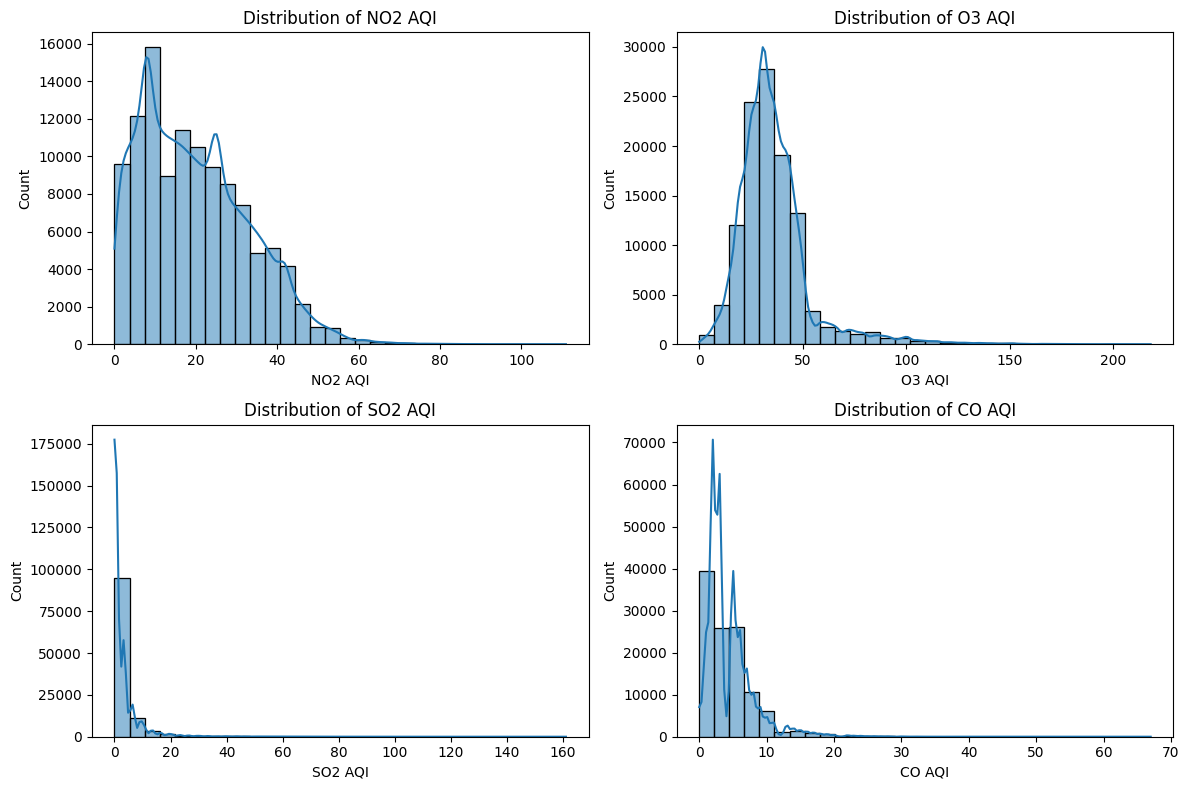

In [ ]:
pollutants = ['NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI']

plt.figure(figsize=(12, 8))
for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)
    sns.histplot(train_final[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


## Time Series Trend of AQI (Daily Mean Across All Sites)

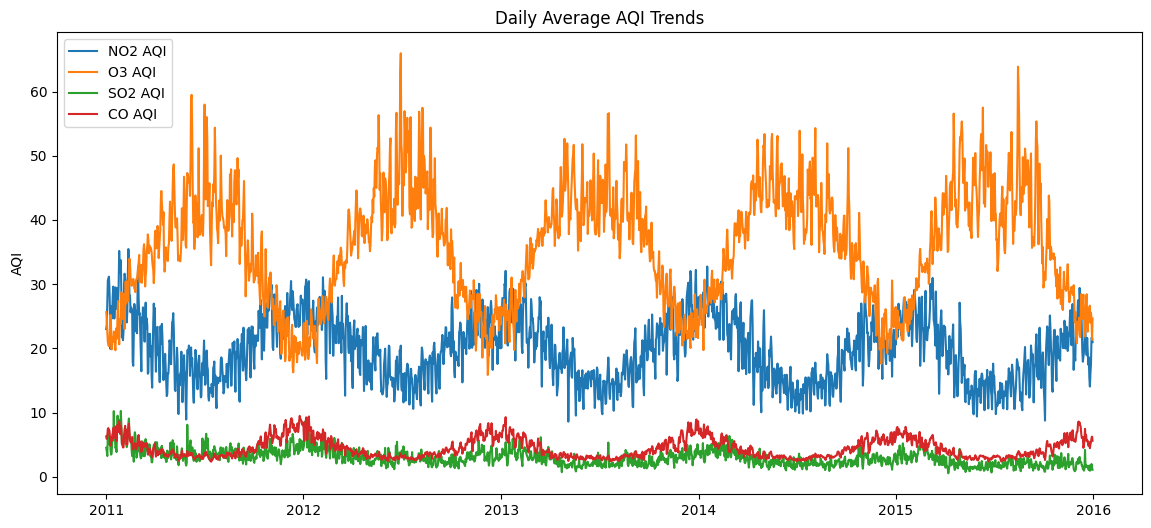

In [ ]:
daily_trend = train_final.groupby('date_local')[pollutants].mean()

plt.figure(figsize=(14, 6))
for col in pollutants:
    plt.plot(daily_trend.index, daily_trend[col], label=col)
plt.legend()
plt.title("Daily Average AQI Trends")
plt.ylabel("AQI")
plt.show()


## Variability Across Sites vs. Across Time

In [ ]:
# Variance across sites (group by date)
site_variance = train_final.groupby('date_local')[pollutants].var().mean()

# Variance across time (group by site)
time_variance = train_final.groupby('site_num')[pollutants].var().mean()

print("Average variance across sites:", site_variance)
print("Average variance across time:", time_variance)

Average variance across sites: NO2 AQI    153.419223
O3 AQI     241.455900
SO2 AQI     40.877821
CO AQI      11.229699
dtype: float64
Average variance across time: NO2 AQI    111.530671
O3 AQI     280.904623
SO2 AQI     34.803253
CO AQI       9.892114
dtype: float64


## Correlation Across Pollutants (Daily Aggregated)

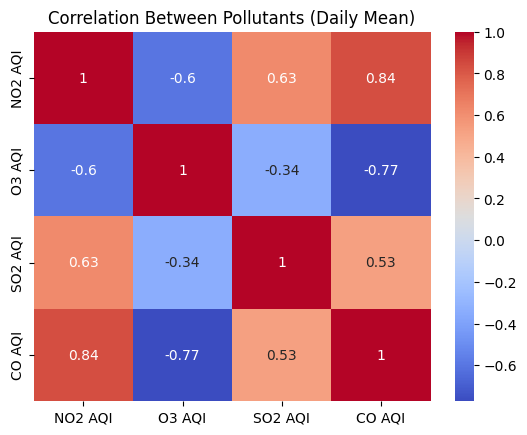

In [ ]:
sns.heatmap(daily_trend.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Pollutants (Daily Mean)")
plt.show()

## Compare Site-Level vs Aggregated AQI

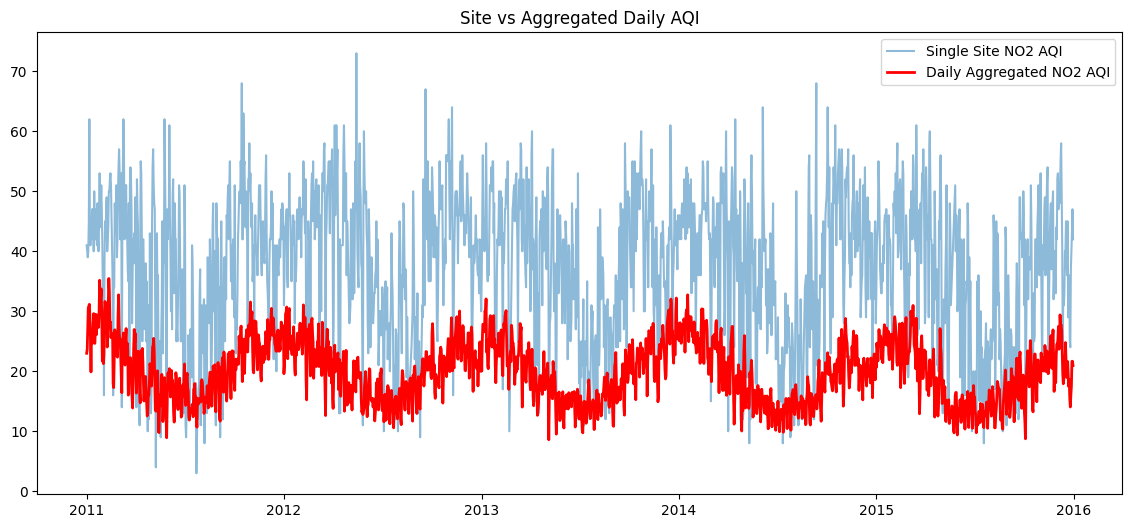

In [ ]:
# For pollutant (NO2)
site_example = train_final[train_final['site_num'] == train_final['site_num'].unique()[0]].groupby('date_local')['NO2 AQI'].mean()

plt.figure(figsize=(14,6))
plt.plot(site_example.index, site_example, alpha=0.5, label="Single Site NO2 AQI")
plt.plot(daily_trend.index, daily_trend['NO2 AQI'], color='red', label="Daily Aggregated NO2 AQI", linewidth=2)
plt.legend()
plt.title("Site vs Aggregated Daily AQI")
plt.show()

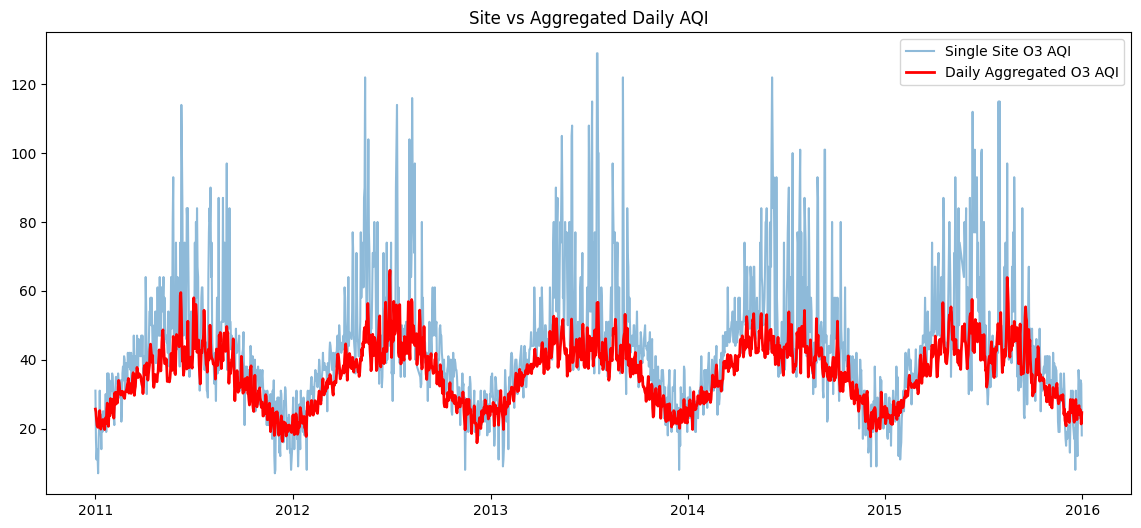

In [ ]:
# For pollutant (O3)
site_example = train_final[train_final['site_num'] == train_final['site_num'].unique()[0]].groupby('date_local')['O3 AQI'].mean()

plt.figure(figsize=(14,6))
plt.plot(site_example.index, site_example, alpha=0.5, label="Single Site O3 AQI")
plt.plot(daily_trend.index, daily_trend['O3 AQI'], color='red', label="Daily Aggregated O3 AQI", linewidth=2)
plt.legend()
plt.title("Site vs Aggregated Daily AQI")
plt.show()

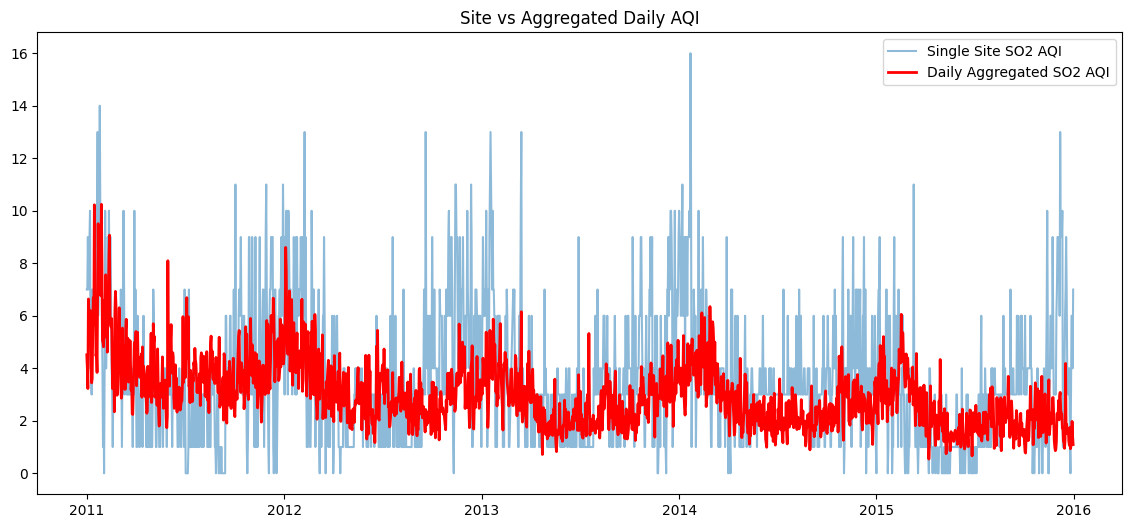

In [ ]:
# For pollutant (SO2)
site_example = train_final[train_final['site_num'] == train_final['site_num'].unique()[0]].groupby('date_local')['SO2 AQI'].mean()

plt.figure(figsize=(14,6))
plt.plot(site_example.index, site_example, alpha=0.5, label="Single Site SO2 AQI")
plt.plot(daily_trend.index, daily_trend['SO2 AQI'], color='red', label="Daily Aggregated SO2 AQI", linewidth=2)
plt.legend()
plt.title("Site vs Aggregated Daily AQI")
plt.show()

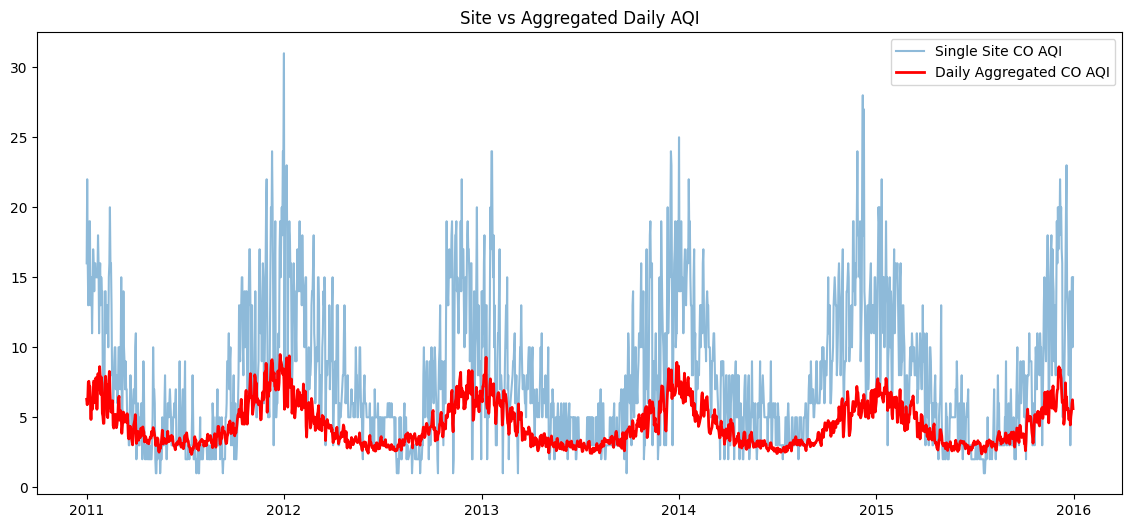

In [ ]:
# For pollutant (CO)
site_example = train_final[train_final['site_num'] == train_final['site_num'].unique()[0]].groupby('date_local')['CO AQI'].mean()

plt.figure(figsize=(14,6))
plt.plot(site_example.index, site_example, alpha=0.5, label="Single Site CO AQI")
plt.plot(daily_trend.index, daily_trend['CO AQI'], color='red', label="Daily Aggregated CO AQI", linewidth=2)
plt.legend()
plt.title("Site vs Aggregated Daily AQI")
plt.show()

## Clustering Sites (to Show Redundancy)

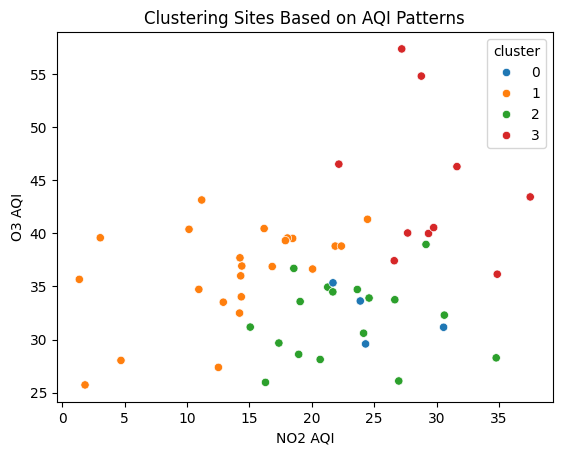

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
X_cluster = train_final.groupby('site_num')[pollutants].mean().dropna()
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_cluster_scaled)

X_cluster['cluster'] = clusters
sns.scatterplot(x=X_cluster['NO2 AQI'], y=X_cluster['O3 AQI'], hue=X_cluster['cluster'], palette="tab10")
plt.title("Clustering Sites Based on AQI Patterns")
plt.show()

## Furthur explore to decide about site-wise forecasting over overall trend forecasting

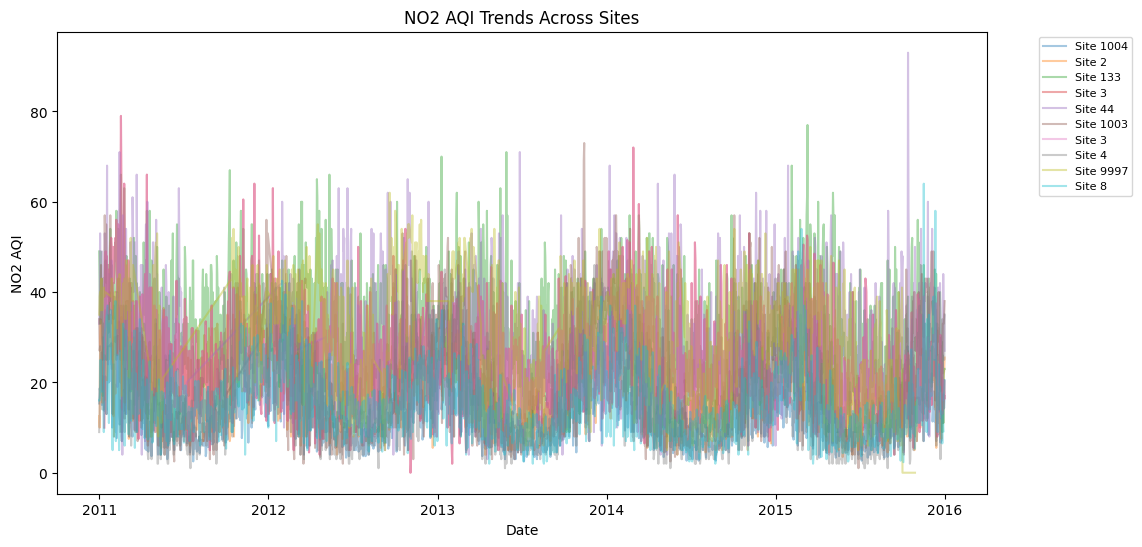

In [ ]:
plt.figure(figsize=(12,6))
for site in train_final['site_num'].sample(10):  # sample 10 sites
    site_data = train_final[train_final['site_num']==site].groupby('date_local')['NO2 AQI'].mean()
    plt.plot(site_data.index, site_data.values, alpha=0.4, label=f"Site {site}")
plt.title("NO2 AQI Trends Across Sites")
plt.xlabel("Date")
plt.ylabel("NO2 AQI")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
plt.show()


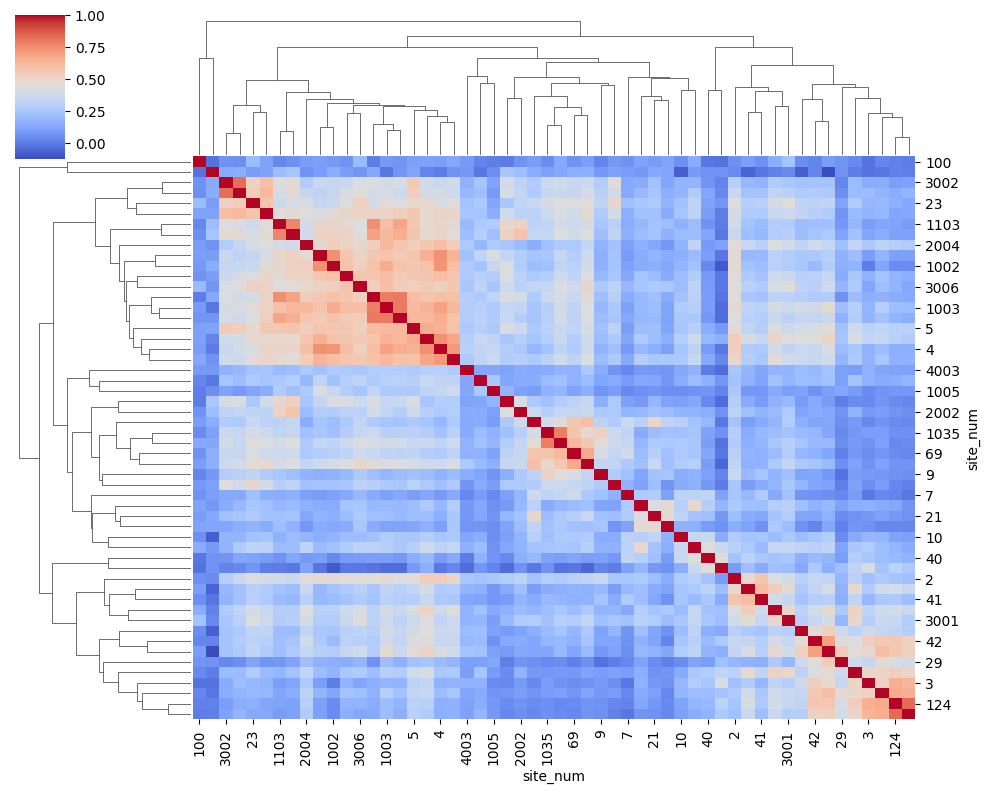

In [ ]:
pivot = train_final.pivot_table(values="NO2 AQI", index="date_local", columns="site_num")
corr = pivot.corr()
sns.clustermap(corr, cmap="coolwarm", figsize=(10,8))

In [ ]:
site_var = train_final.groupby("site_num")["NO2 AQI"].var().mean()
overall_var = train_final.groupby("date_local")["NO2 AQI"].mean().var()
print("Average site variance:", site_var)
print("Overall variance:", overall_var)

Average site variance: 111.53067083252606
Overall variance: 25.639441760259007


## Aggregation

In [ ]:
# --- Aggregate TRAIN ---
daily_train = (
    train_final
    .groupby('date_local')[['NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI']]
    .mean()          # average across all sites for each day
    .sort_index()    # ensure chronological order
)

# --- Aggregate TEST ---
daily_test = (
    test_final
    .groupby('date_local')[['NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI']]
    .mean()
    .sort_index()
)

print("Train daily shape:", daily_train.shape)
print("Test daily shape:", daily_test.shape)

print("\nTrain range:", daily_train.index.min(), "to", daily_train.index.max())
print("Test range:", daily_test.index.min(), "to", daily_test.index.max())


Train daily shape: (1826, 4)
Test daily shape: (152, 4)

Train range: 2011-01-01 00:00:00 to 2015-12-31 00:00:00
Test range: 2016-01-01 00:00:00 to 2016-05-31 00:00:00


In [ ]:
daily_train.isna().sum()

,0
NO2 AQI,0
O3 AQI,0
SO2 AQI,0
CO AQI,0


In [ ]:
daily_test.isna().sum()

,0
NO2 AQI,0
O3 AQI,0
SO2 AQI,0
CO AQI,0


# Initial Modeling

## Average Method

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Score table
pollutants = ['NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI']
mindex = pd.MultiIndex.from_product(
    [['RMSE', 'MAE'], ['Average', 'Naive', 'Seasonal_Naive']]
)
fc_scores = pd.DataFrame(index=mindex, columns=pollutants)

def store_scores(model_name, predictions):
    for pol in pollutants:
        rmse = mean_squared_error(daily_test[pol], predictions[pol])
        mae  = mean_absolute_error(daily_test[pol], predictions[pol])
        fc_scores.loc[('RMSE', model_name), pol] = rmse
        fc_scores.loc[('MAE', model_name), pol] = mae

In [ ]:
def plot_forecast(predictions, title):
    for pol in pollutants:
        plt.figure(figsize=(12, 5))
        plt.plot(daily_train.index, daily_train[pol], label='Train', alpha=0.6)
        plt.plot(daily_test.index, daily_test[pol], label='Test', alpha=0.8)
        plt.plot(predictions.index, predictions[pol], label=f'Forecast ({title})', linestyle='--')
        plt.title(f'{pol} - {title} Forecast')
        plt.xlabel("Date")
        plt.ylabel("AQI")
        plt.legend()
        plt.show()

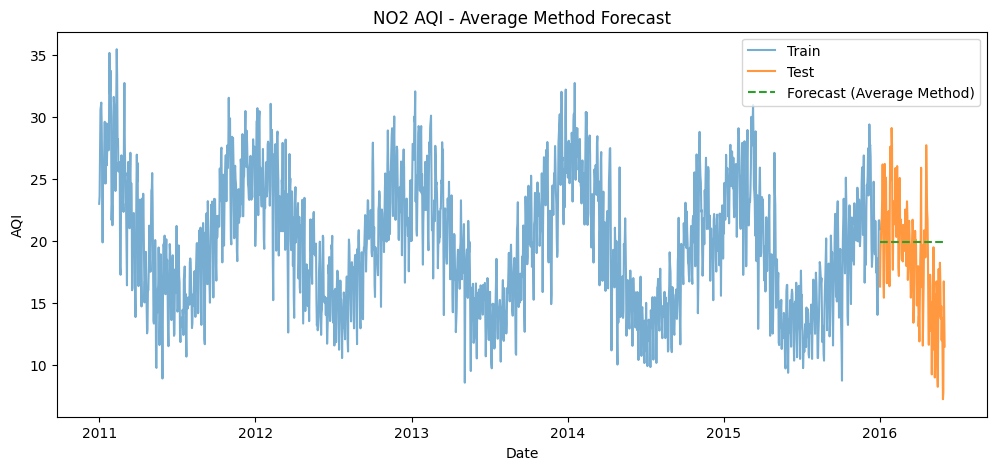

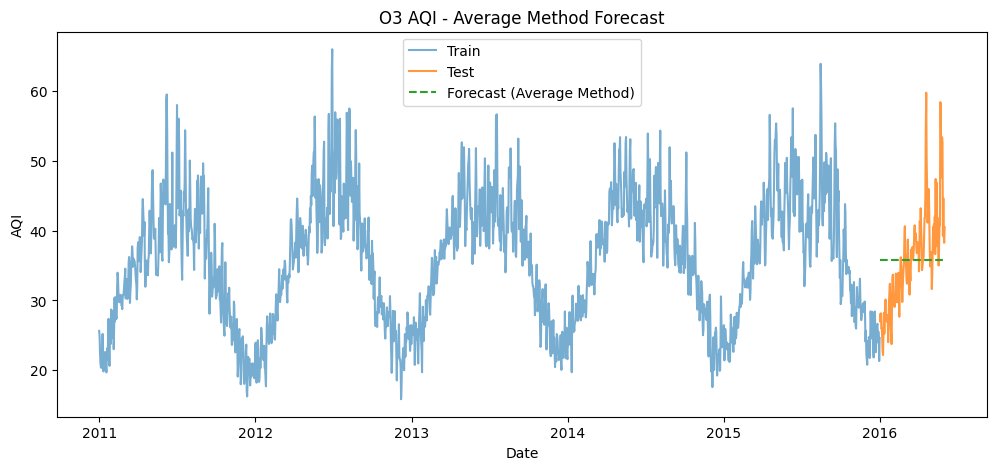

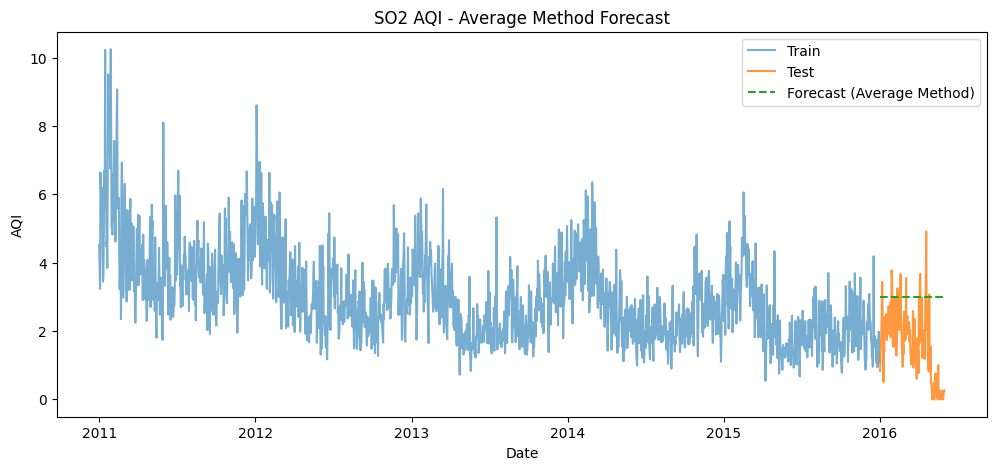

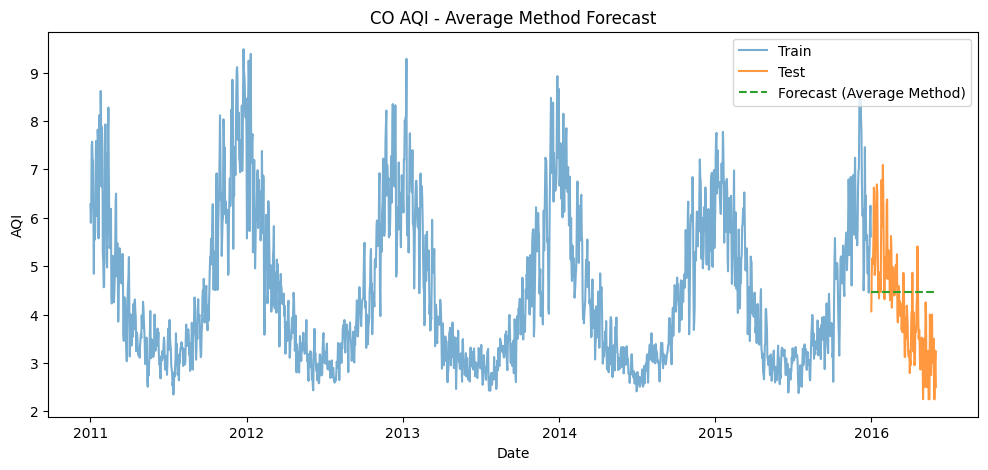

In [ ]:
avg_predictions = pd.DataFrame(index=daily_test.index, columns=pollutants)
for pol in pollutants:
    avg_predictions[pol] = daily_train[pol].mean()

store_scores('Average', avg_predictions)
plot_forecast(avg_predictions, "Average Method")

## Naïve Method

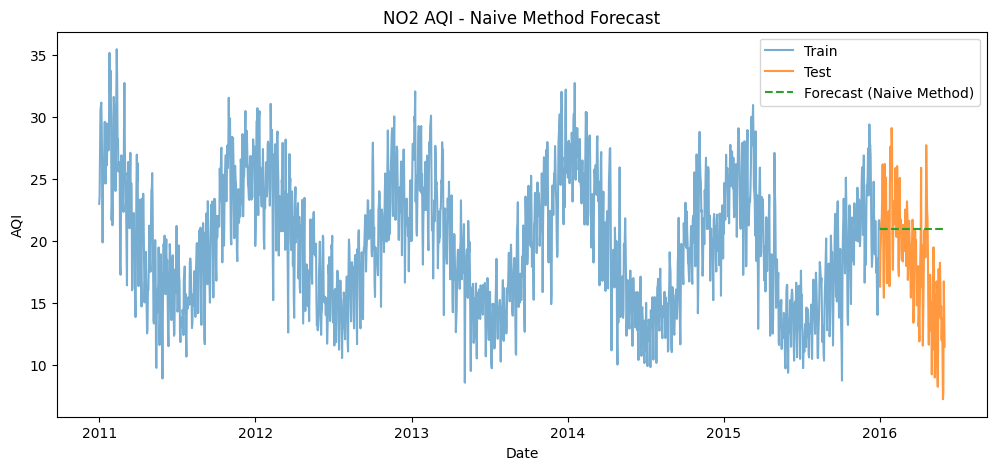

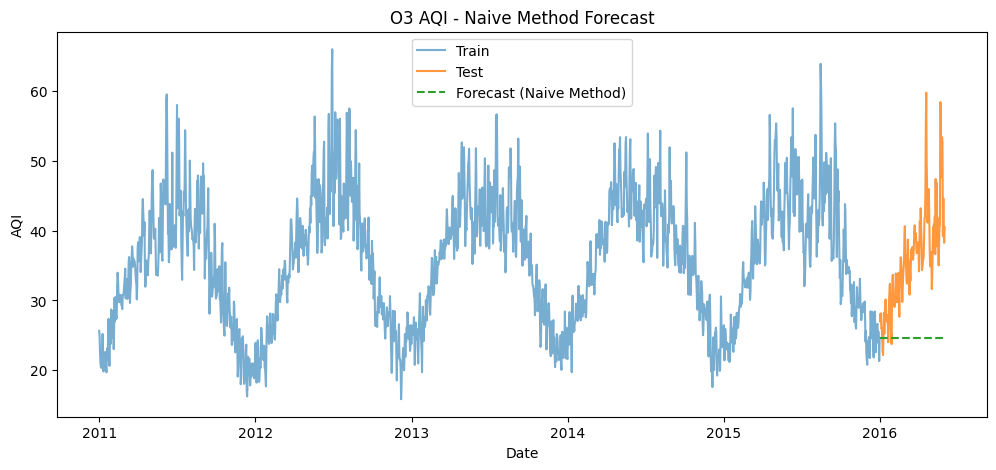

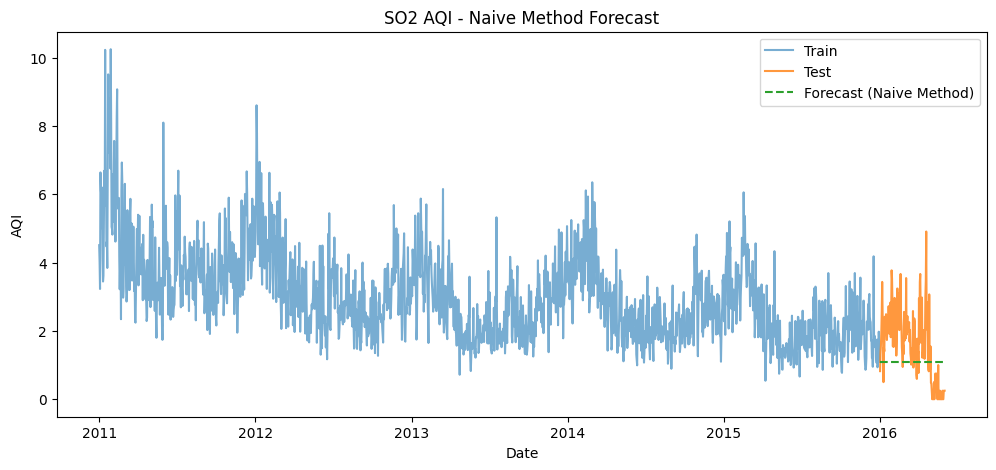

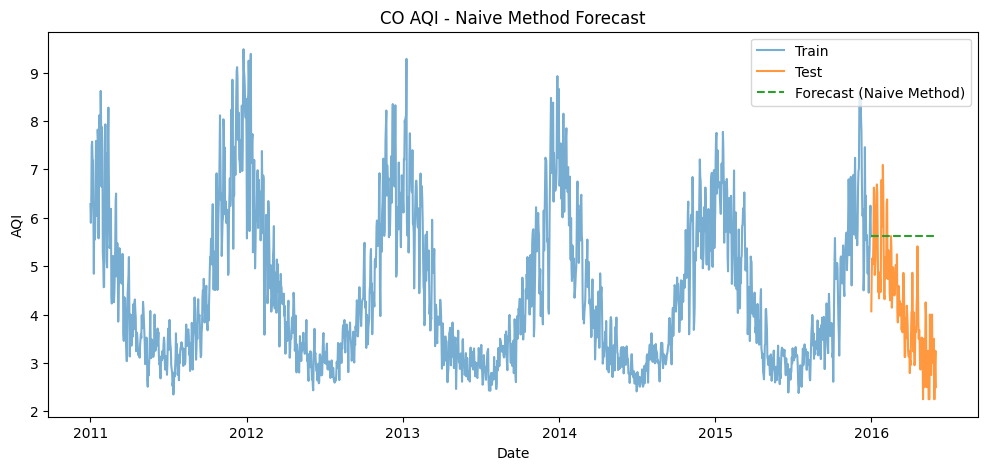

In [ ]:
naive_predictions = pd.DataFrame(index=daily_test.index, columns=pollutants)
for pol in pollutants:
    naive_predictions[pol] = daily_train[pol].iloc[-1]

store_scores('Naive', naive_predictions)
plot_forecast(naive_predictions, "Naive Method")

## Seasonal Naïve Method

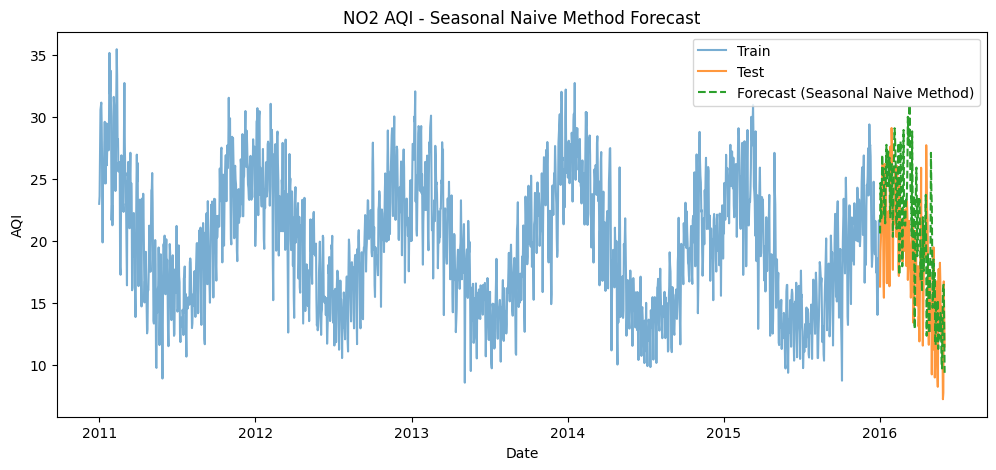

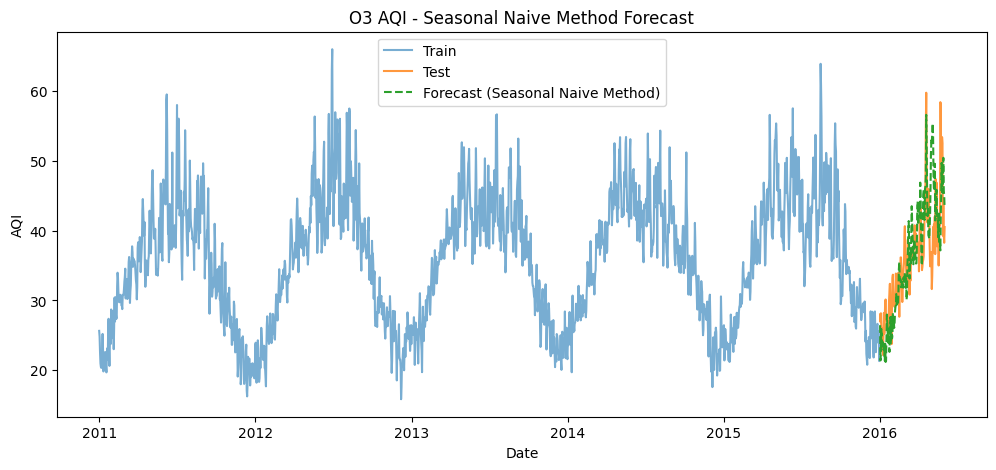

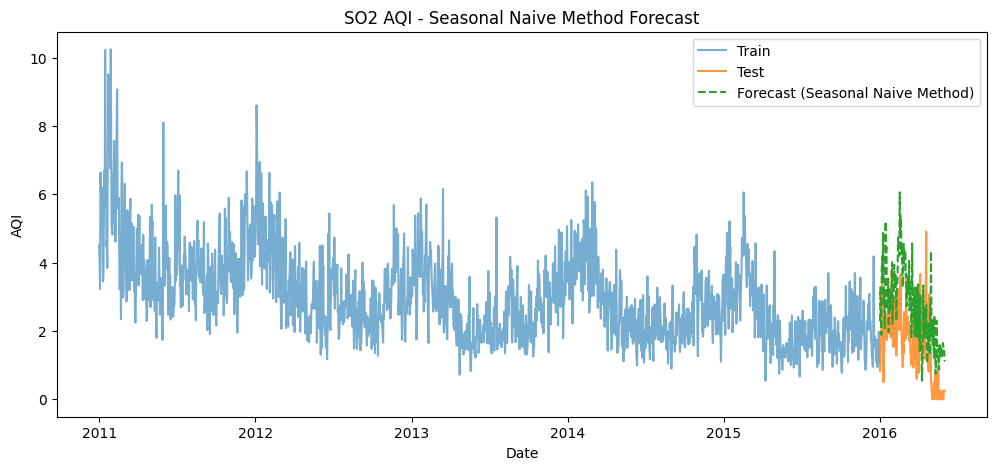

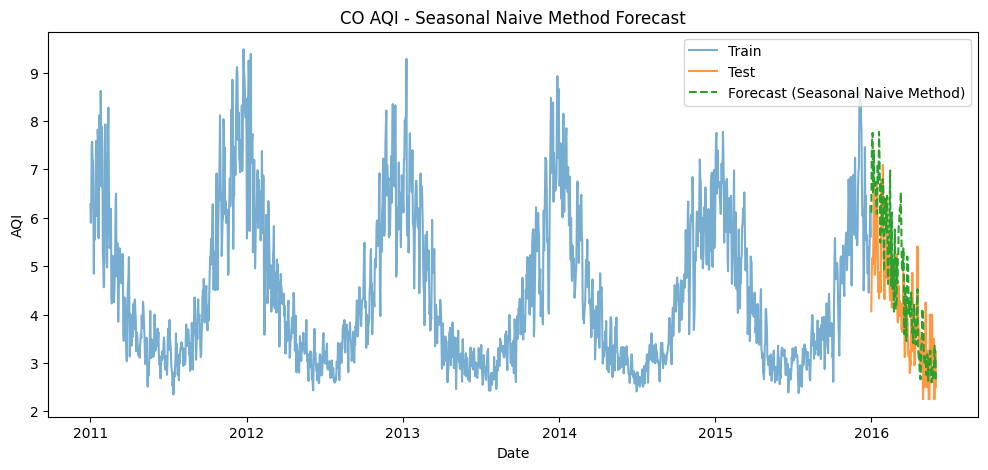

In [ ]:
sn_predictions = pd.DataFrame(index=daily_test.index, columns=pollutants)

# Shift by 1 year
for pol in pollutants:
    # Aggregate train data by date to handle potential duplicate dates
    daily_train_agg = daily_train.groupby(daily_train.index).mean()
    for date in daily_test.index:
        prev_year = date - pd.DateOffset(years=1)
        if prev_year in daily_train_agg.index:
            sn_predictions.loc[date, pol] = daily_train_agg.loc[prev_year, pol]
        else:
            # fallback for leap day → use Feb 28
            if prev_year.month == 2 and prev_year.day == 29:
                fallback = pd.Timestamp(prev_year.year, 2, 28)
                if fallback in daily_train_agg.index:
                    sn_predictions.loc[date, pol] = daily_train_agg.loc[fallback, pol]

store_scores('Seasonal_Naive', sn_predictions)
plot_forecast(sn_predictions, "Seasonal Naive Method")

In [ ]:
print(fc_scores)

                       NO2 AQI      O3 AQI   SO2 AQI    CO AQI
RMSE Average         22.423763   48.904301  2.882372  1.276084
     Naive           26.408451  175.498094  1.404261  3.260385
     Seasonal_Naive  29.948937   35.726647  2.403641  1.233395
MAE  Average          3.768008    5.244551  1.433376  0.918376
     Naive            4.012002   11.328745   0.98409  1.576332
     Seasonal_Naive   4.334407    4.346619  1.328944  0.854604


# Prophet

In [ ]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly


--- Prophet Forecasting for NO2 AQI ---


DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/nt881wfp.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/xsslq_yv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=40160', 'data', 'file=/tmp/tmp3fbf_bi1/nt881wfp.json', 'init=/tmp/tmp3fbf_bi1/xsslq_yv.json', 'output', 'file=/tmp/tmp3fbf_bi1/prophet_modelhad12ynp/prophet_model-20250901162313.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:23:13 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:23:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


NO2 AQI → RMSE: 3.299, MAE: 2.650


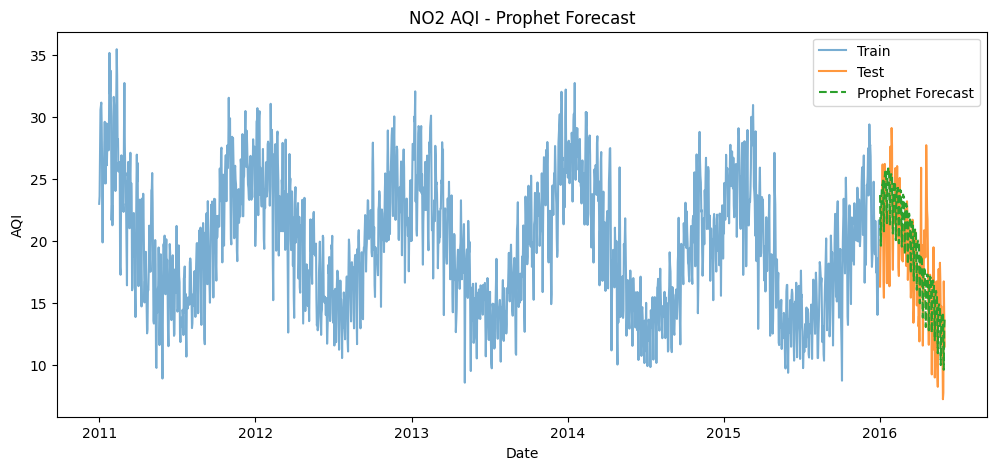

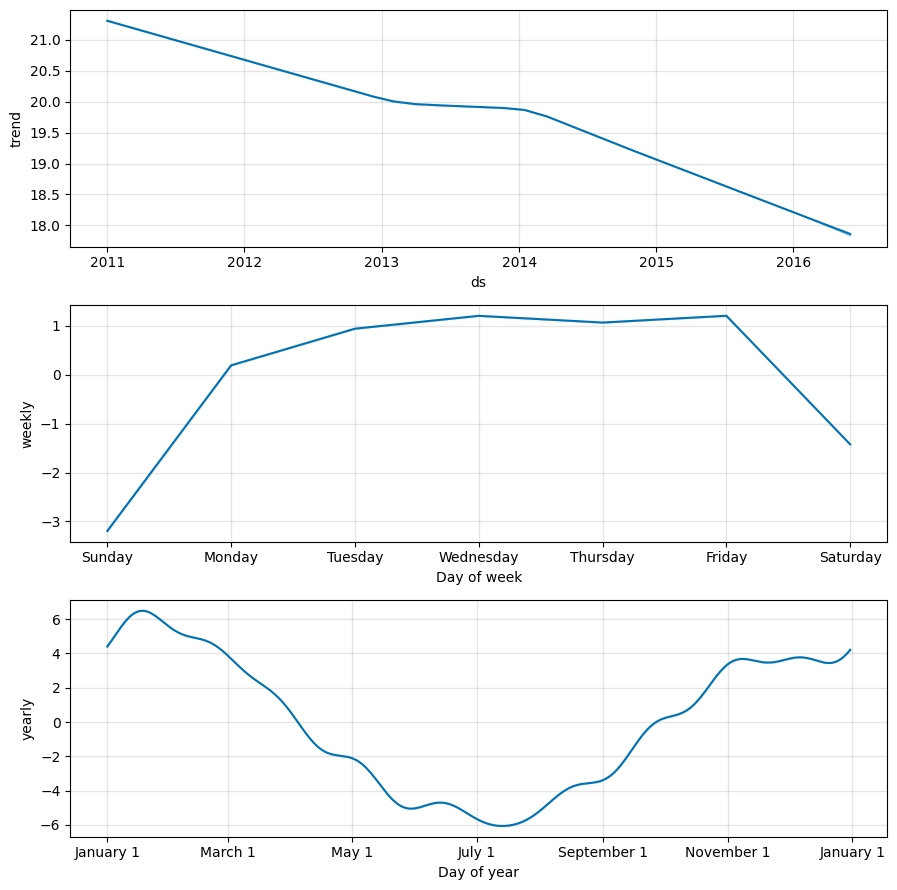

DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/ylbbysr7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/anq4ofsg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=14392', 'data', 'file=/tmp/tmp3fbf_bi1/ylbbysr7.json', 'init=/tmp/tmp3fbf_bi1/anq4ofsg.json', 'output', 'file=/tmp/tmp3fbf_bi1/prophet_model2l0om2pa/prophet_model-20250901162314.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:23:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing



--- Prophet Forecasting for O3 AQI ---


16:23:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


O3 AQI → RMSE: 4.926, MAE: 3.708


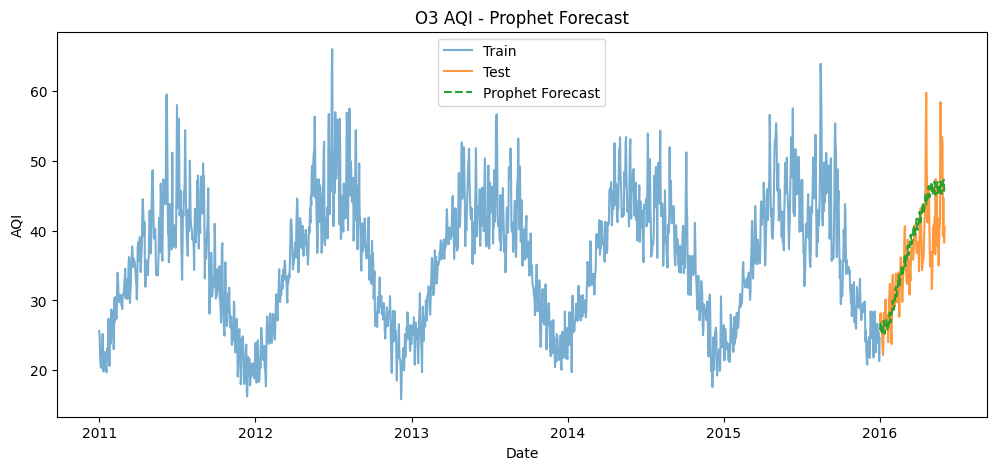

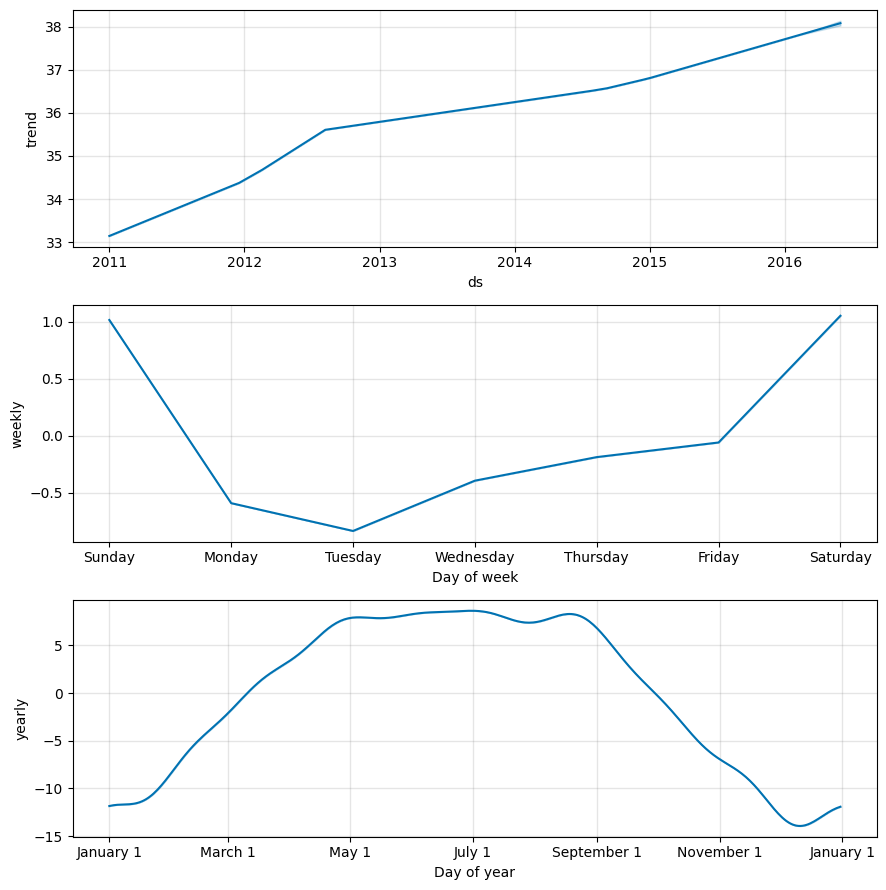

DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/fv31r8w4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/yirqkgio.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=5711', 'data', 'file=/tmp/tmp3fbf_bi1/fv31r8w4.json', 'init=/tmp/tmp3fbf_bi1/yirqkgio.json', 'output', 'file=/tmp/tmp3fbf_bi1/prophet_modelgij0i99m/prophet_model-20250901162316.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:23:16 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing



--- Prophet Forecasting for SO2 AQI ---


16:23:16 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


SO2 AQI → RMSE: 1.012, MAE: 0.844


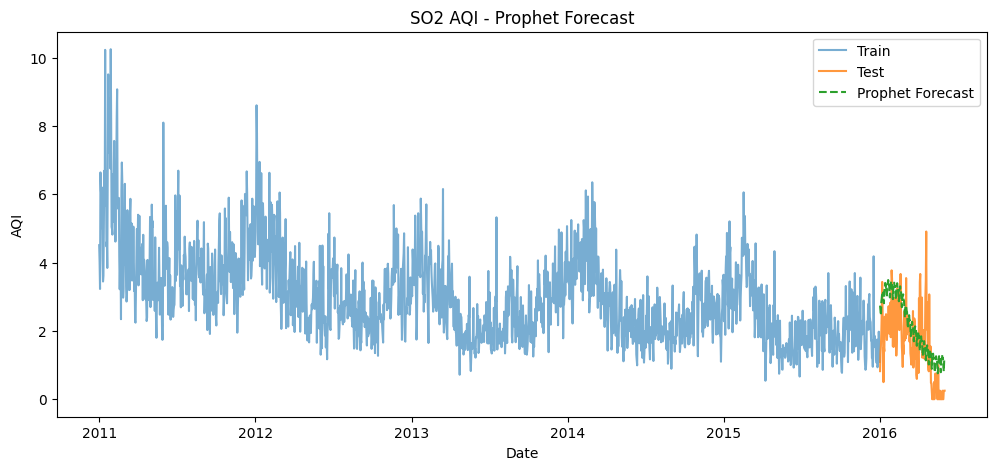

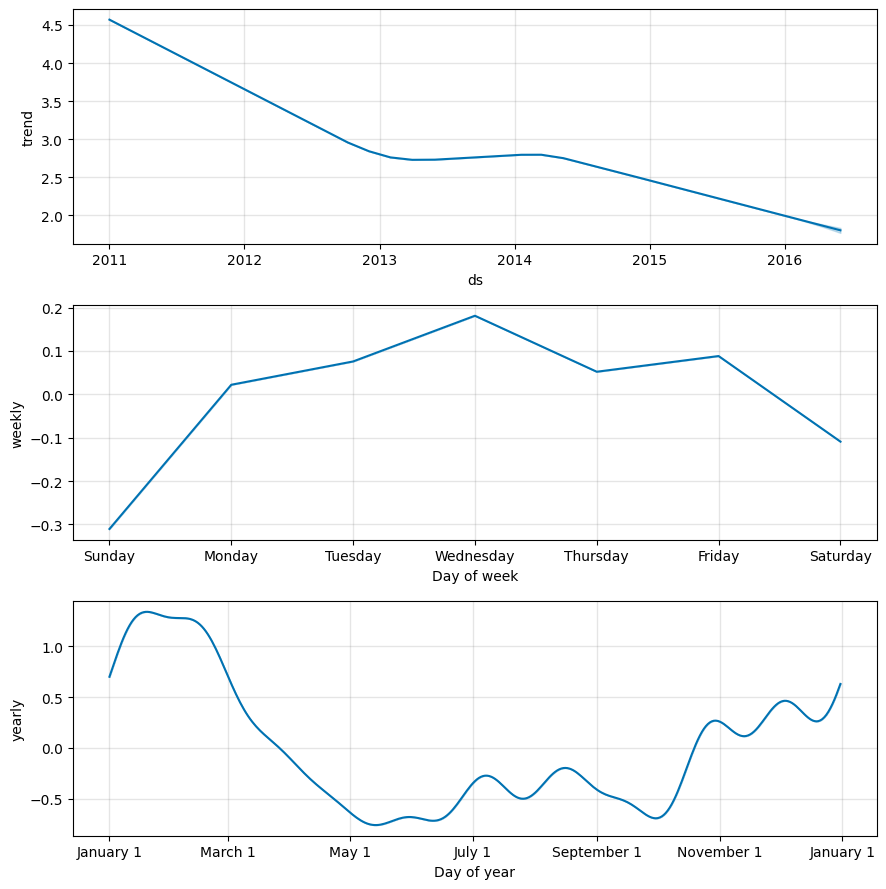

DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/23tn2blr.json



--- Prophet Forecasting for CO AQI ---


DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/srj2kgrv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=21019', 'data', 'file=/tmp/tmp3fbf_bi1/23tn2blr.json', 'init=/tmp/tmp3fbf_bi1/srj2kgrv.json', 'output', 'file=/tmp/tmp3fbf_bi1/prophet_model41p3dlmg/prophet_model-20250901162317.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:23:17 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:23:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


CO AQI → RMSE: 0.884, MAE: 0.685


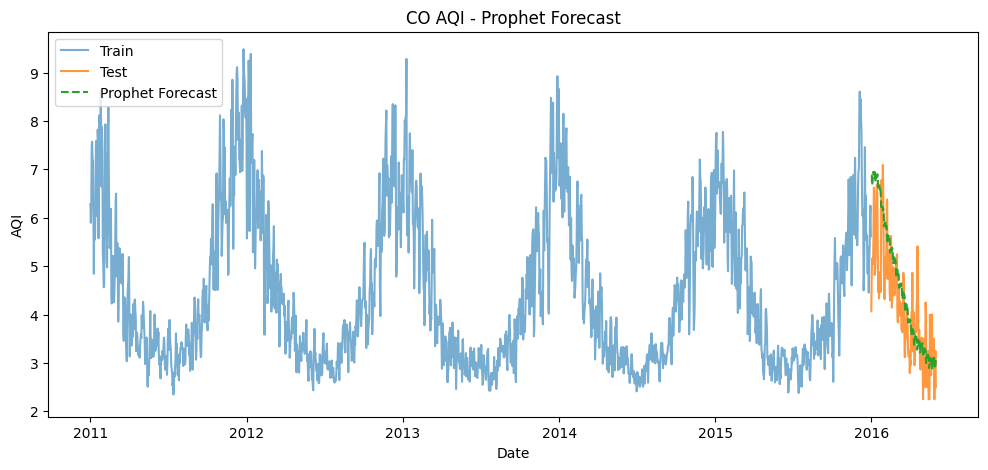

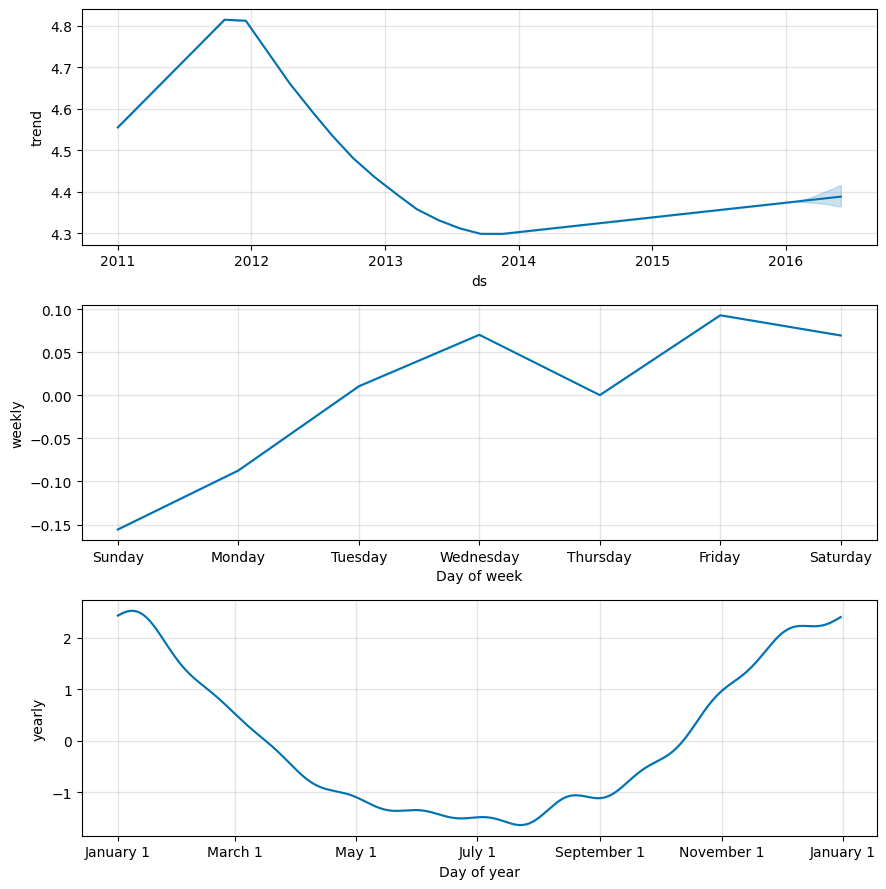


Forecasting Model Comparison:
               NO2 AQI    O3 AQI   SO2 AQI    CO AQI
RMSE Prophet   3.29905  4.926287  1.012076   0.88367
MAE  Prophet  2.650411  3.707514  0.843808  0.684982


In [ ]:
prophet_scores = pd.DataFrame(index=pd.MultiIndex.from_product([['RMSE','MAE'], ['Prophet']]), columns=pollutants)
prophet_predictions = {}

# Store Prophet forecasts
prophet_predictions = {}

for pol in pollutants:
    print(f"\n--- Prophet Forecasting for {pol} ---")

    # Prepare train/test in Prophet format
    train_df = daily_train[[pol]].reset_index().rename(columns={'date_local': 'ds', pol: 'y'})
    test_df  = daily_test[[pol]].reset_index().rename(columns={'date_local': 'ds', pol: 'y'})

    # Fit Prophet model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    model.fit(train_df)

    # Create future dataframe (same length as test set)
    future = model.make_future_dataframe(periods=len(test_df), freq='D')
    forecast = model.predict(future)

    # Align forecast with test set
    forecast_test = forecast.set_index('ds').loc[test_df['ds']]
    prophet_predictions[pol] = forecast_test['yhat']

    # Evaluate
    rmse = np.sqrt(mean_squared_error(test_df['y'], forecast_test['yhat']))
    mae = mean_absolute_error(test_df['y'], forecast_test['yhat'])

    prophet_scores.loc[('RMSE', 'Prophet'), pol] = rmse
    prophet_scores.loc[('MAE', 'Prophet'), pol] = mae

    print(f"{pol} → RMSE: {rmse:.3f}, MAE: {mae:.3f}")

    # --- Visualization ---
    plt.figure(figsize=(12, 5))
    plt.plot(daily_train.index, daily_train[pol], label='Train', alpha=0.6)
    plt.plot(daily_test.index, daily_test[pol], label='Test', alpha=0.8)
    plt.plot(test_df['ds'], forecast_test['yhat'], label='Prophet Forecast', linestyle='--')
    plt.title(f'{pol} - Prophet Forecast')
    plt.xlabel("Date")
    plt.ylabel("AQI")
    plt.legend()
    plt.show()

    # Prophet decomposition plot (great for storytelling)
    model.plot_components(forecast)
    plt.show()

# ------------------------------------------------------------------
# Final Scores Table
# ------------------------------------------------------------------
print("\nForecasting Model Comparison:")
print(prophet_scores)

## Feature Engineered Prophet

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/iieqwn7a.json



--- Feature-Engineered Prophet Forecasting for NO2 AQI ---


DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/oy9vc1mo.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=34698', 'data', 'file=/tmp/tmp3fbf_bi1/iieqwn7a.json', 'init=/tmp/tmp3fbf_bi1/oy9vc1mo.json', 'output', 'file=/tmp/tmp3fbf_bi1/prophet_modelqrf89m48/prophet_model-20250901162331.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:23:31 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:23:31 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


NO2 AQI → RMSE: 2.833, MAE: 2.150


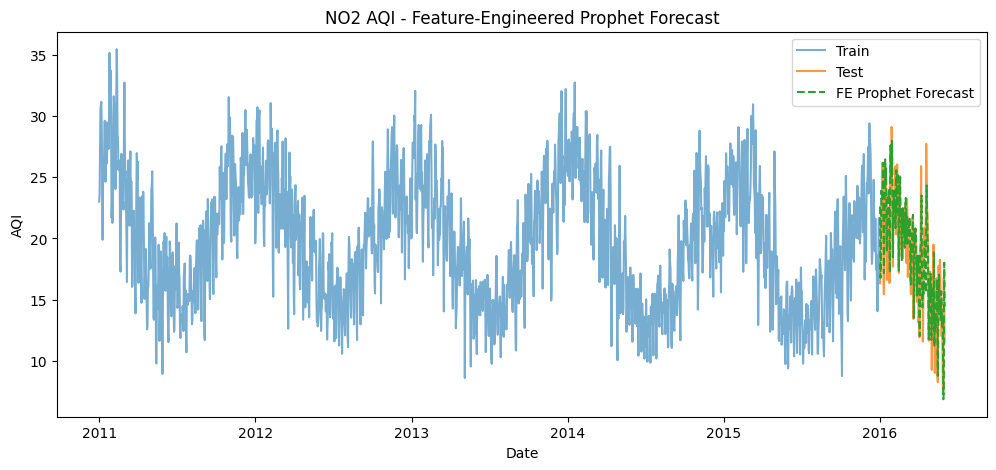

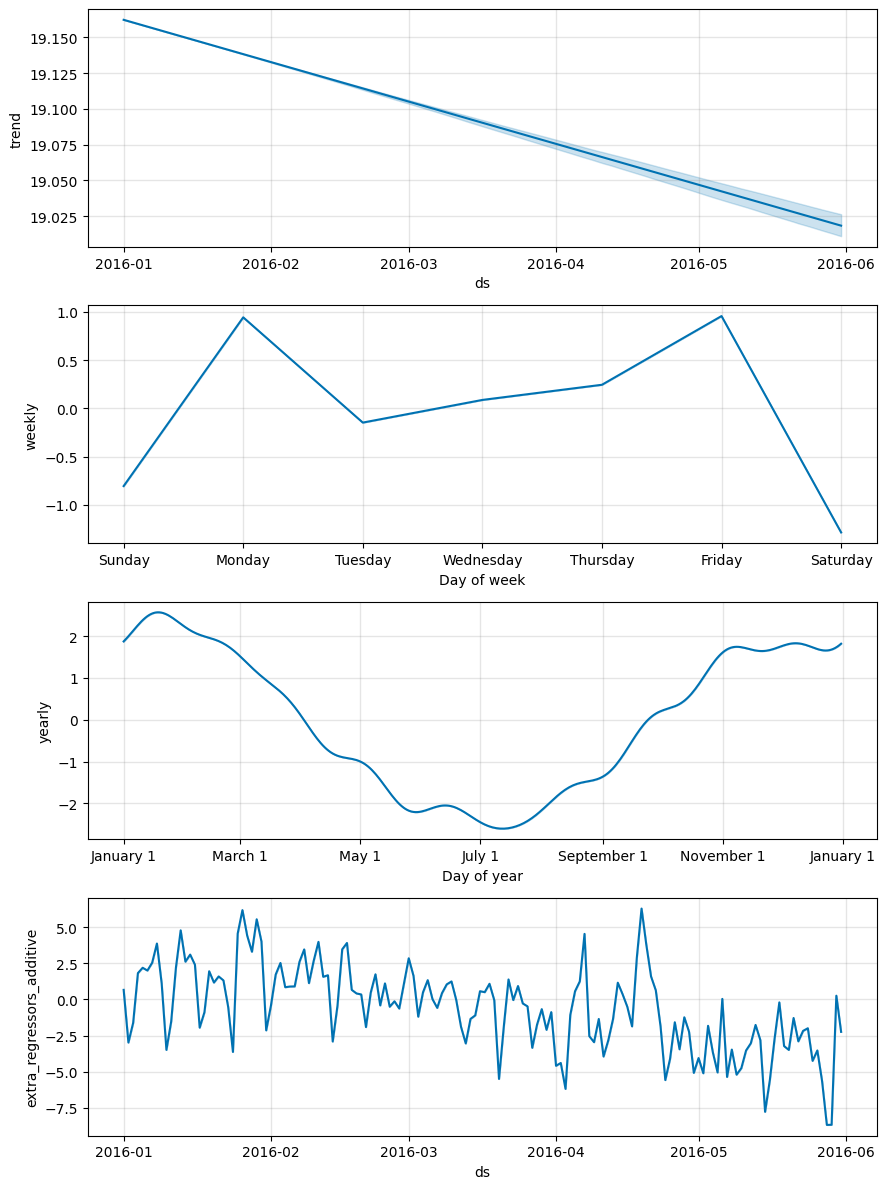

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/28v5hxe0.json



--- Feature-Engineered Prophet Forecasting for O3 AQI ---


DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/_9434_sk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=14199', 'data', 'file=/tmp/tmp3fbf_bi1/28v5hxe0.json', 'init=/tmp/tmp3fbf_bi1/_9434_sk.json', 'output', 'file=/tmp/tmp3fbf_bi1/prophet_modelxc8rctmi/prophet_model-20250901162332.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:23:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:23:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


O3 AQI → RMSE: 3.376, MAE: 2.411


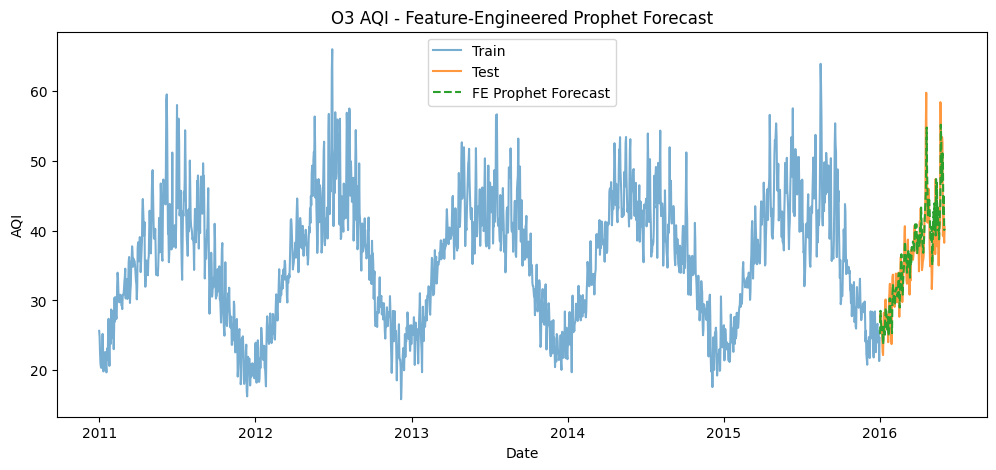

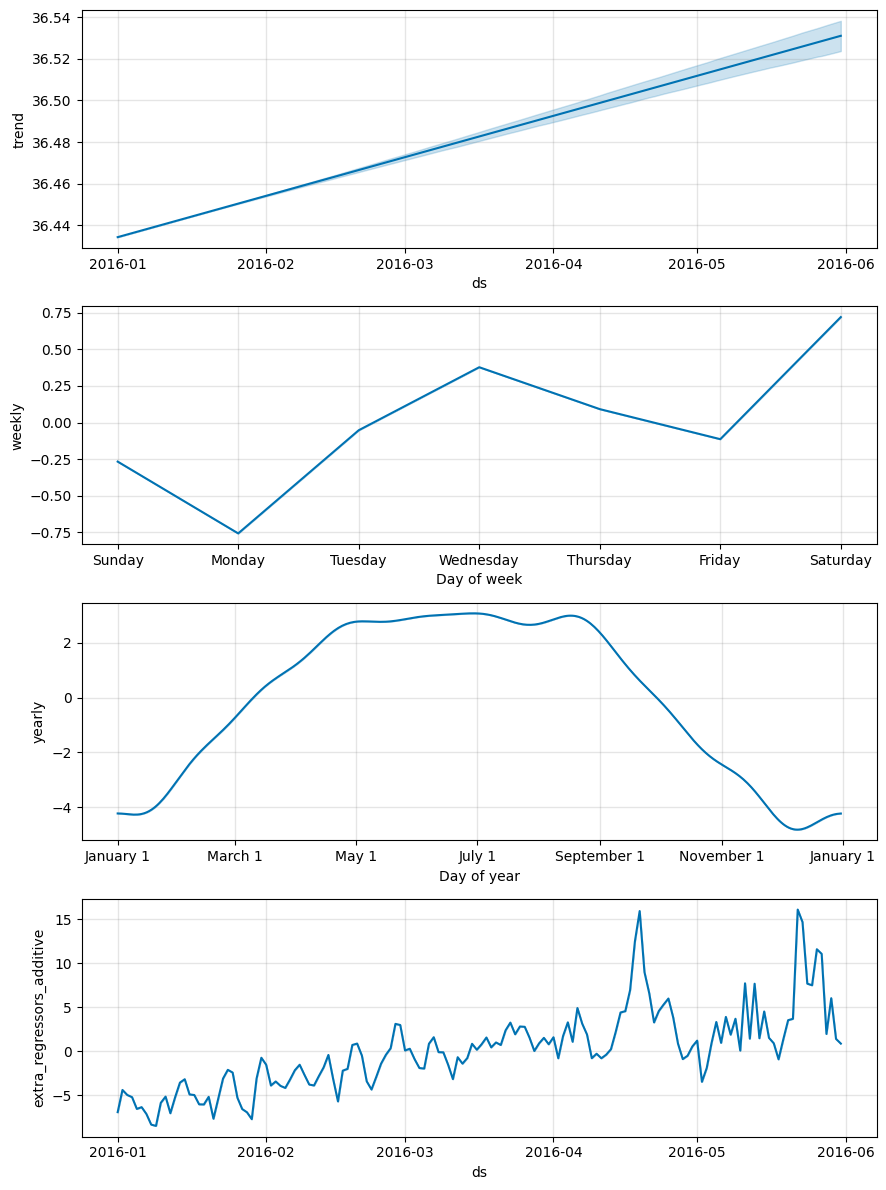

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/8wskdb5a.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/ieemz3oq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=61720', 'data', 'file=/tmp/tmp3fbf_bi1/8wskdb5a.json', 'init=/tmp/tmp3fbf_bi1/ieemz3oq.json', 'output', 'file=/tmp/tmp3fbf_bi1/prophet_modelkq8o4wjx/prophet_model-20250901162334.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:23:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing



--- Feature-Engineered Prophet Forecasting for SO2 AQI ---


16:23:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


SO2 AQI → RMSE: 0.746, MAE: 0.589


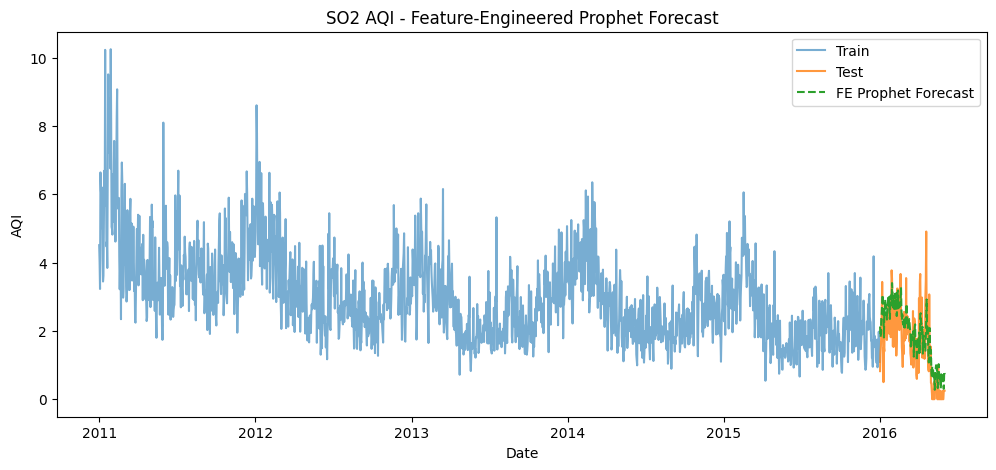

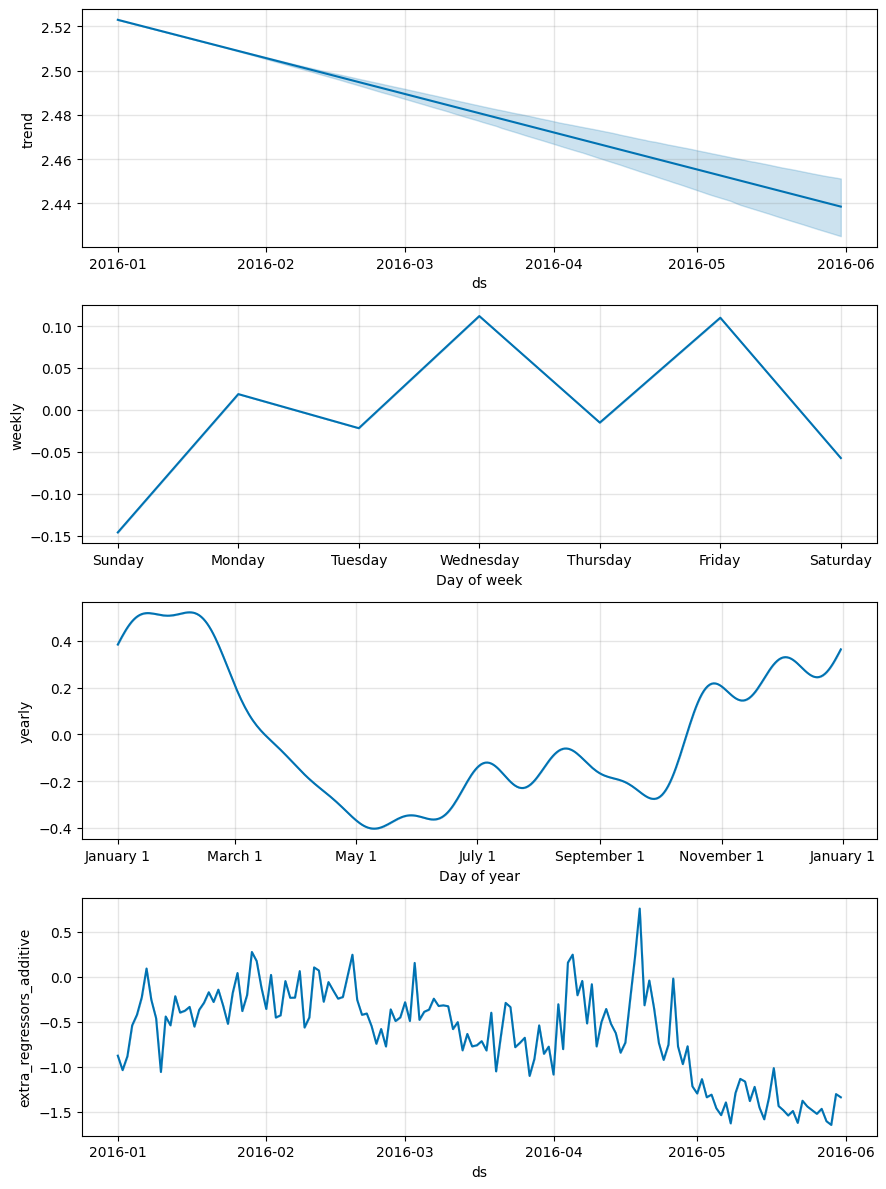

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/lkui2zb5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3fbf_bi1/8o9sl6je.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19988', 'data', 'file=/tmp/tmp3fbf_bi1/lkui2zb5.json', 'init=/tmp/tmp3fbf_bi1/8o9sl6je.json', 'output', 'file=/tmp/tmp3fbf_bi1/prophet_model2crkbnk7/prophet_model-20250901162336.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:23:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing



--- Feature-Engineered Prophet Forecasting for CO AQI ---


16:23:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


CO AQI → RMSE: 0.604, MAE: 0.476


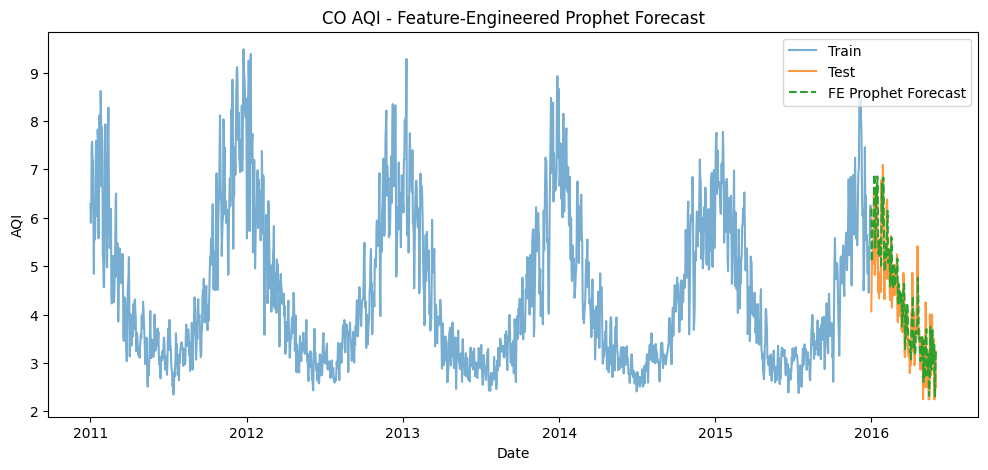

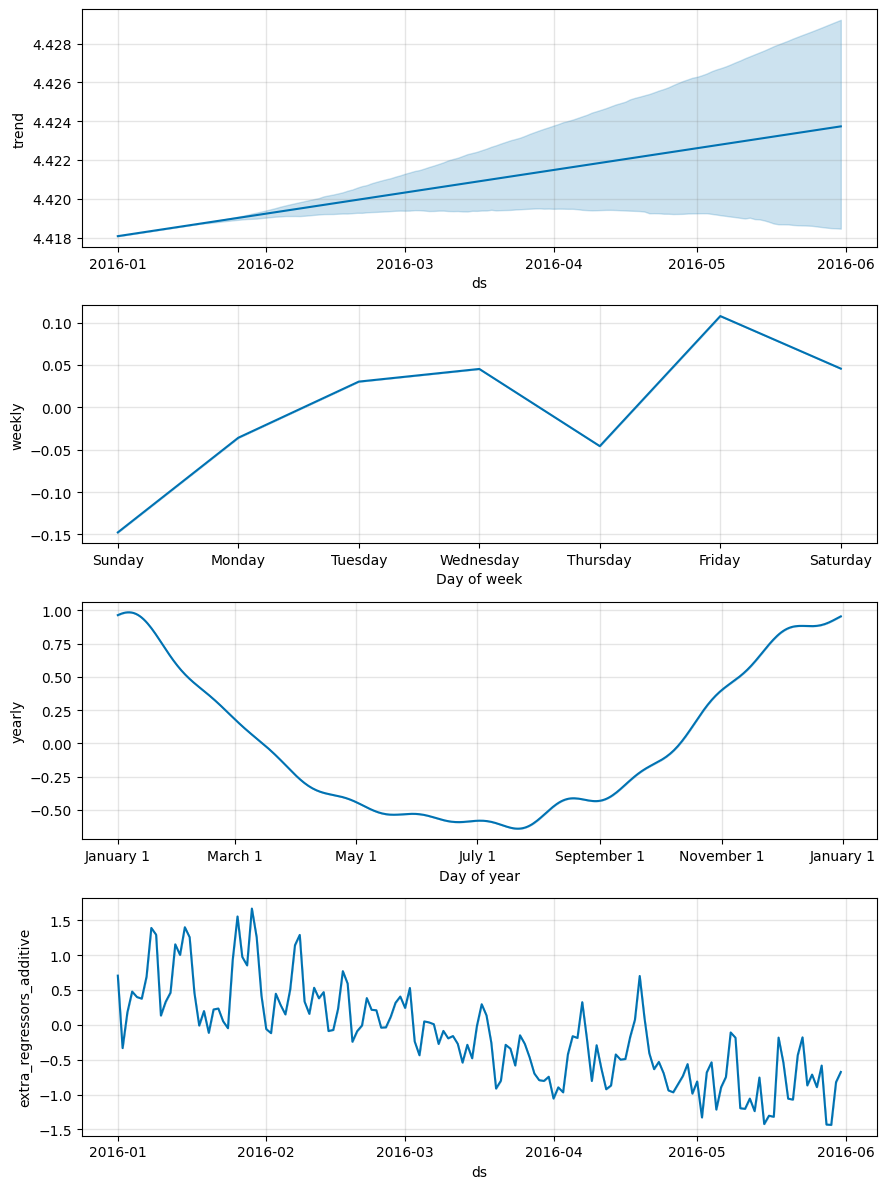


Feature-Engineered Prophet Forecasting Scores:
                  NO2 AQI    O3 AQI   SO2 AQI    CO AQI
RMSE FE_Prophet  2.832635  3.376068  0.745553  0.604216
MAE  FE_Prophet  2.150137  2.410764  0.589192  0.475989


In [ ]:
# Separate score table for feature-engineered Prophet
fe_prophet_scores = pd.DataFrame(index=pd.MultiIndex.from_product([['RMSE','MAE'], ['FE_Prophet']]), columns=pollutants)
fe_prophet_predictions = {}

for pol in pollutants:
    print(f"\n--- Feature-Engineered Prophet Forecasting for {pol} ---")

    # Dataframes specific to feature-engineered Prophet
    fe_train_df = daily_train[[pol]].reset_index().rename(columns={'date_local':'ds', pol:'y'})
    fe_test_df  = daily_test[[pol]].reset_index().rename(columns={'date_local':'ds', pol:'y'})

    # Add simple features
    for df_ in [fe_train_df, fe_test_df]:
        df_['day_of_week'] = df_['ds'].dt.dayofweek
        df_['month'] = df_['ds'].dt.month

    # Lag and rolling mean (train only)
    fe_train_df['lag1'] = fe_train_df['y'].shift(1)
    fe_train_df['rolling_mean7'] = fe_train_df['y'].shift(1).rolling(7).mean()
    fe_train_df = fe_train_df.dropna()

    # Align test lag1 and rolling_mean7 with train
    last_train = fe_train_df.tail(7)
    fe_test_df['lag1'] = pd.concat([fe_train_df['y'].iloc[-1:], fe_test_df['y'][:-1]]).values
    rolling_prev = pd.concat([last_train['y'], fe_test_df['y']])
    fe_test_df['rolling_mean7'] = rolling_prev.shift(1).rolling(7).mean().iloc[7:].values

    # Initialize separate Prophet model
    fe_model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
    for reg in ['day_of_week','month','lag1','rolling_mean7']:
        fe_model.add_regressor(reg)

    # Fit and forecast
    fe_model.fit(fe_train_df)
    fe_forecast = fe_model.predict(fe_test_df)
    fe_prophet_predictions[pol] = fe_forecast['yhat'].values

    # Evaluate
    rmse = np.sqrt(mean_squared_error(fe_test_df['y'], fe_forecast['yhat']))
    mae = mean_absolute_error(fe_test_df['y'], fe_forecast['yhat'])
    fe_prophet_scores.loc[('RMSE','FE_Prophet'), pol] = rmse
    fe_prophet_scores.loc[('MAE','FE_Prophet'), pol] = mae

    print(f"{pol} → RMSE: {rmse:.3f}, MAE: {mae:.3f}")

    # Plot forecast
    plt.figure(figsize=(12,5))
    plt.plot(daily_train.index, daily_train[pol], label='Train', alpha=0.6)
    plt.plot(daily_test.index, daily_test[pol], label='Test', alpha=0.8)
    plt.plot(fe_test_df['ds'], fe_forecast['yhat'], label='FE Prophet Forecast', linestyle='--')
    plt.title(f'{pol} - Feature-Engineered Prophet Forecast')
    plt.xlabel("Date")
    plt.ylabel("AQI")
    plt.legend()
    plt.show()

    # Decomposition plot
    fe_model.plot_components(fe_forecast)
    plt.show()

print("\nFeature-Engineered Prophet Forecasting Scores:")
print(fe_prophet_scores)

# XG Boost with Engineered Features


--- XGBoost Forecasting for NO2 AQI ---
NO2 AQI → RMSE: 3.049, MAE: 2.373


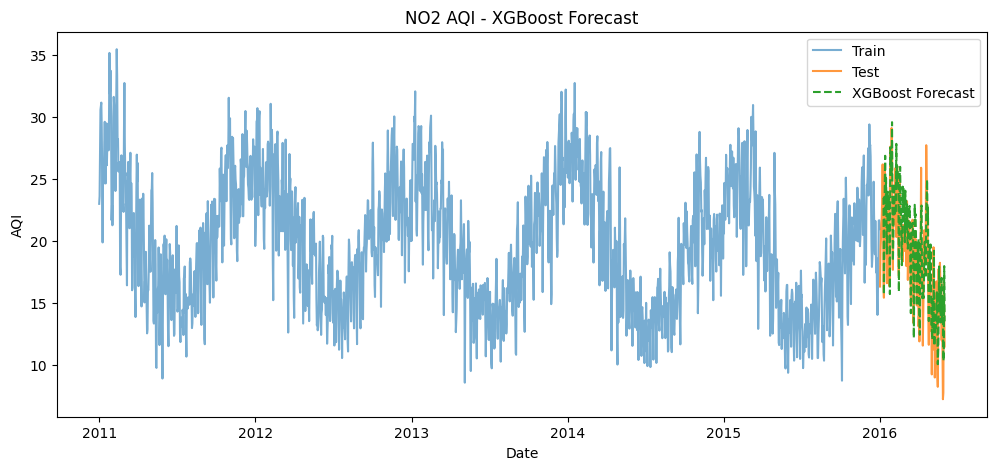


--- XGBoost Forecasting for O3 AQI ---
O3 AQI → RMSE: 3.890, MAE: 2.664


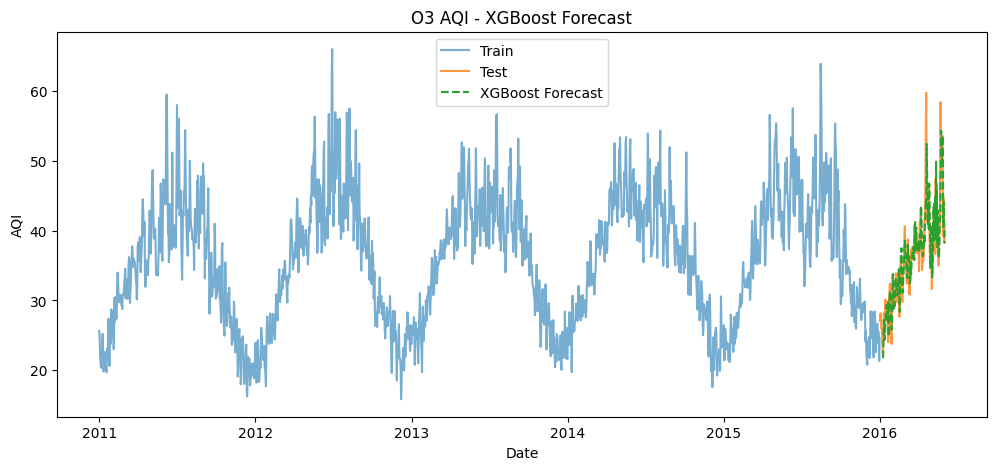


--- XGBoost Forecasting for SO2 AQI ---
SO2 AQI → RMSE: 0.942, MAE: 0.770


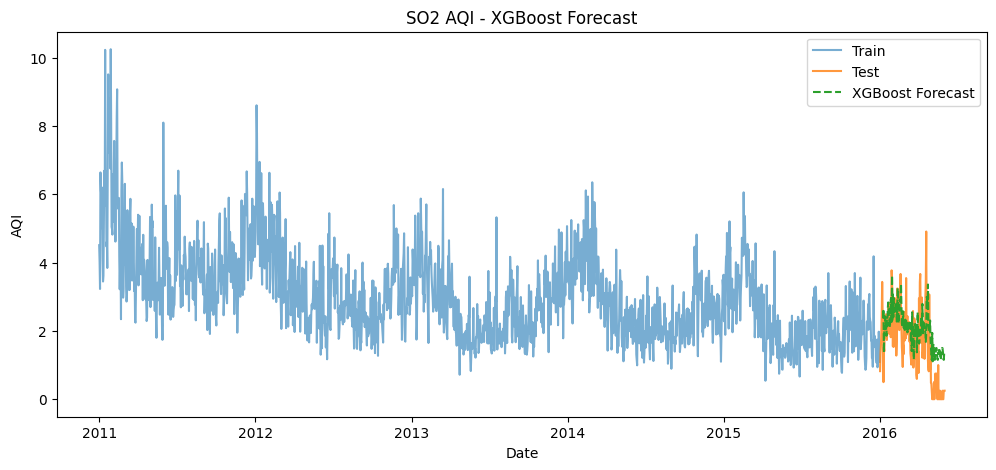


--- XGBoost Forecasting for CO AQI ---
CO AQI → RMSE: 0.600, MAE: 0.478


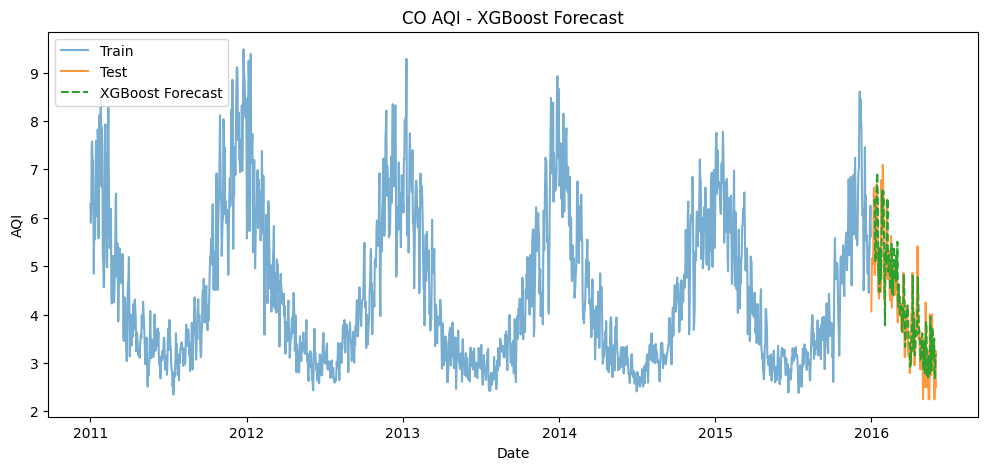


XGBoost Forecasting Scores:
               NO2 AQI    O3 AQI   SO2 AQI    CO AQI
RMSE XGBoost  3.049325  3.889915  0.942223  0.599787
MAE  XGBoost  2.372989  2.663667  0.769707  0.478187


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

pollutants = ['NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI']

# Separate score table for XGBoost
xgb_scores = pd.DataFrame(index=pd.MultiIndex.from_product([['RMSE','MAE'], ['XGBoost']]), columns=pollutants)
xgb_predictions = {}

# Function to create lag and rolling features
def create_features(df, target_col):
    df_feat = df.copy()
    df_feat['day_of_week'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    df_feat['lag1'] = df_feat[target_col].shift(1)
    df_feat['lag7'] = df_feat[target_col].shift(7)
    df_feat['rolling_mean7'] = df_feat[target_col].shift(1).rolling(7).mean()
    return df_feat.dropna()

for pol in pollutants:
    print(f"\n--- XGBoost Forecasting for {pol} ---")

    # Create features
    train_feat = create_features(daily_train[[pol]], pol)
    test_feat = create_features(pd.concat([daily_train[[pol]].iloc[-7:], daily_test[[pol]]]), pol)

    # Align features: drop first rows in test corresponding to NaNs
    test_feat = test_feat.iloc[7:]

    X_train = train_feat.drop(columns=[pol])
    y_train = train_feat[pol]
    X_test  = test_feat.drop(columns=[pol])
    y_test  = test_feat[pol]

    # Initialize and train XGBoost
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    xgb_predictions[pol] = y_pred

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    xgb_scores.loc[('RMSE','XGBoost'), pol] = rmse
    xgb_scores.loc[('MAE','XGBoost'), pol] = mae

    print(f"{pol} → RMSE: {rmse:.3f}, MAE: {mae:.3f}")

    # Plot forecast
    plt.figure(figsize=(12,5))
    plt.plot(daily_train.index, daily_train[pol], label='Train', alpha=0.6)
    plt.plot(daily_test.index, daily_test[pol], label='Test', alpha=0.8)
    plt.plot(test_feat.index, y_pred, label='XGBoost Forecast', linestyle='--')
    plt.title(f'{pol} - XGBoost Forecast')
    plt.xlabel("Date")
    plt.ylabel("AQI")
    plt.legend()
    plt.show()

print("\nXGBoost Forecasting Scores:")
print(xgb_scores)
